In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('data/raw.csv')

In [3]:
df.head()

,gender,race,education,lunch,course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
df.shape

(1000, 8)

In [5]:
df['race'].value_counts()

race
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64

In [6]:
df.isna().sum()

gender           0
race             0
education        0
lunch            0
course           0
math_score       0
reading_score    0
writing_score    0
dtype: int64

In [7]:
df.isnull().sum()

gender           0
race             0
education        0
lunch            0
course           0
math_score       0
reading_score    0
writing_score    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   gender         1000 non-null   str  
 1   race           1000 non-null   str  
 2   education      1000 non-null   str  
 3   lunch          1000 non-null   str  
 4   course         1000 non-null   str  
 5   math_score     1000 non-null   int64
 6   reading_score  1000 non-null   int64
 7   writing_score  1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [10]:
df.nunique()

gender            2
race              5
education         6
lunch             2
course            2
math_score       81
reading_score    72
writing_score    77
dtype: int64

In [11]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [12]:
df['race'].dtype

<StringDtype(storage='python', na_value=nan)>

In [13]:
df.columns

Index(['gender', 'race', 'education', 'lunch', 'course', 'math_score',
       'reading_score', 'writing_score'],
      dtype='str')

In [14]:
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'str']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'str']

print("We have {} Numerical Features : {}".format(len(numeric_features), numeric_features))
print("We have {} Categorical Features : {}".format(len(categorical_features), categorical_features))

We have 3 Numerical Features : ['math_score', 'reading_score', 'writing_score']
We have 5 Categorical Features : ['gender', 'race', 'education', 'lunch', 'course']


In [15]:
# df.drop(columns=['average_score'], inplace= True)

In [16]:
df['total_score'] = df['math_score'] + df['reading_score'] + df['writing_score']
df['average'] = round(df['total_score'] / 3, 2)

df.head()

,gender,race,education,lunch,course,math_score,reading_score,writing_score,total_score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.67
1,female,group C,some college,standard,completed,69,90,88,247,82.33
2,female,group B,master's degree,standard,none,90,95,93,278,92.67
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.33
4,male,group C,some college,standard,none,76,78,75,229,76.33


In [17]:
df.head()

,gender,race,education,lunch,course,math_score,reading_score,writing_score,total_score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.67
1,female,group C,some college,standard,completed,69,90,88,247,82.33
2,female,group B,master's degree,standard,none,90,95,93,278,92.67
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.33
4,male,group C,some college,standard,none,76,78,75,229,76.33


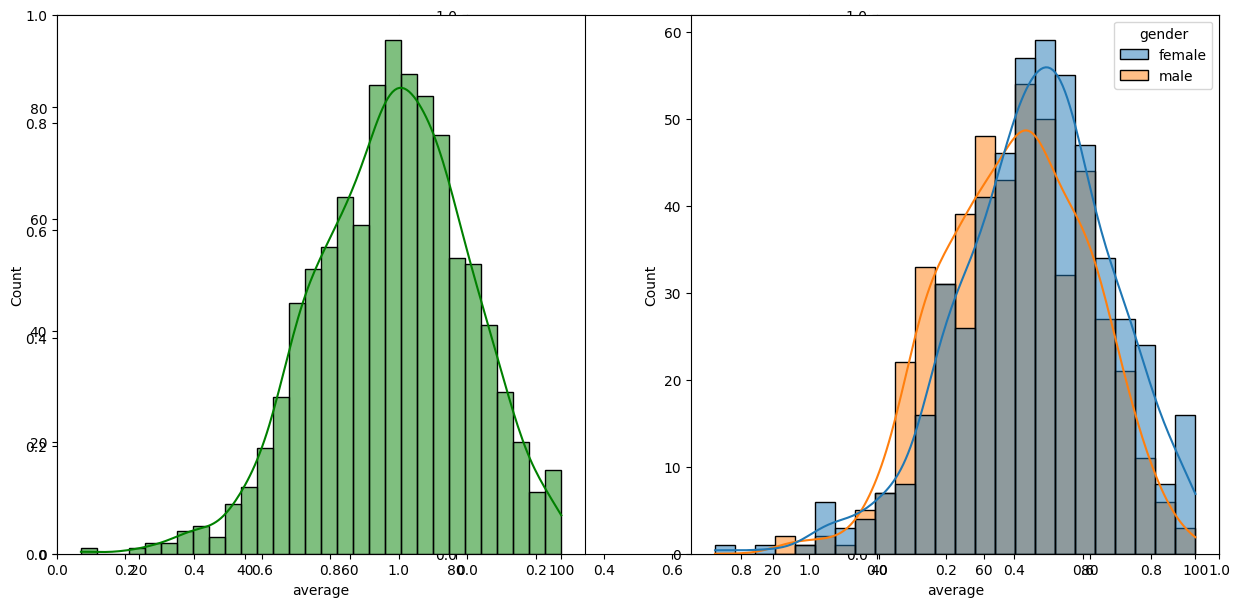

In [18]:
fig, axs = plt.subplots(1, 3, figsize = (15, 7))
plt.subplot(121)
sns.histplot(data=df, x='average', bins = 30, kde=True, color='g')
plt.subplot(122)
sns.histplot(data=df, x='average', kde=True, hue='gender')
plt.show()


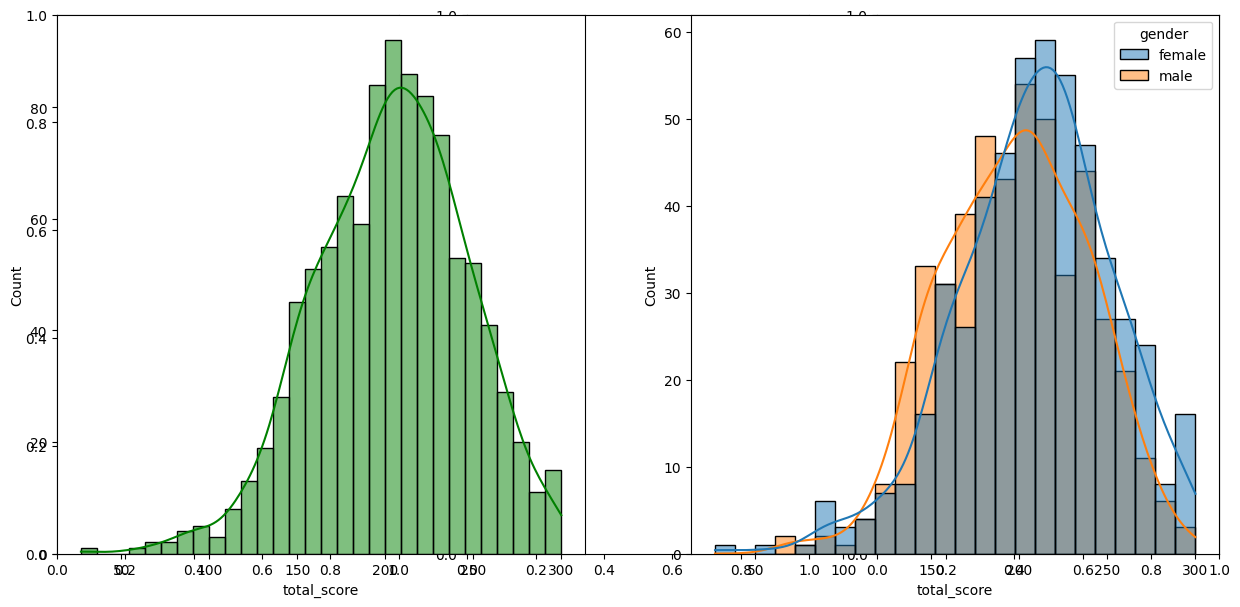

In [19]:
fig, axs = plt.subplots(1, 3, figsize = (15, 7))
plt.subplot(121)
sns.histplot(data=df, x='total_score', bins = 30, kde=True, color='g')
plt.subplot(122)
sns.histplot(data=df, x='total_score', kde=True, hue='gender')
plt.show()

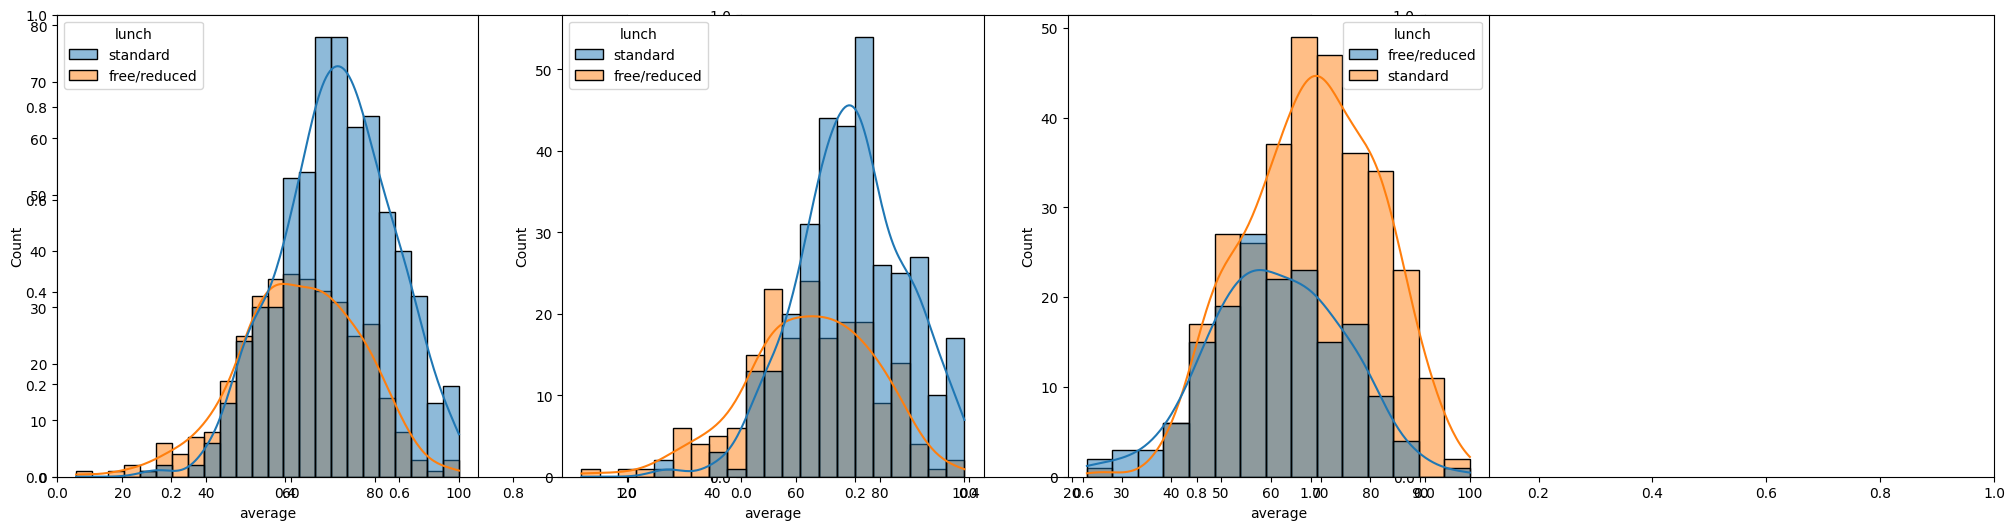

In [20]:
plt.subplots(1, 3, figsize = (25, 6))
plt.subplot(141)
sns.histplot(data = df, x = 'average', kde = True, hue = 'lunch')
plt.subplot(142)
sns.histplot(data = df[df.gender == 'female'], x = 'average', kde = True, hue = 'lunch')
plt.subplot(143)
sns.histplot(data = df[df.gender == 'male'], x = 'average', kde = True, hue = 'lunch')
plt.show()

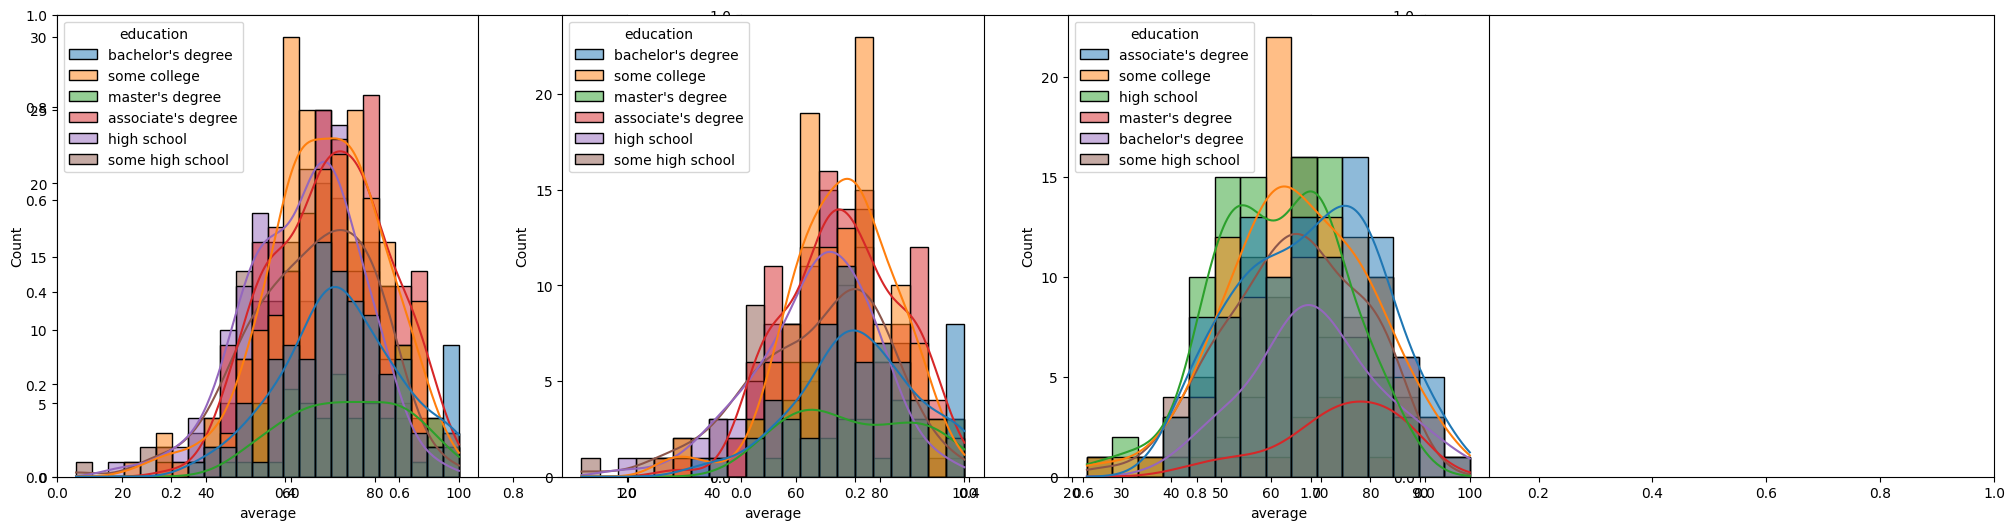

In [21]:
plt.subplots(1, 3, figsize = (25, 6))
plt.subplot(141)
sns.histplot(data = df, x = 'average', kde = True, hue = 'education')
plt.subplot(142)
sns.histplot(data = df[df.gender == 'female'], x = 'average', kde = True, hue = 'education')
plt.subplot(143)
sns.histplot(data = df[df.gender == 'male'], x = 'average', kde = True, hue = 'education')
plt.show()

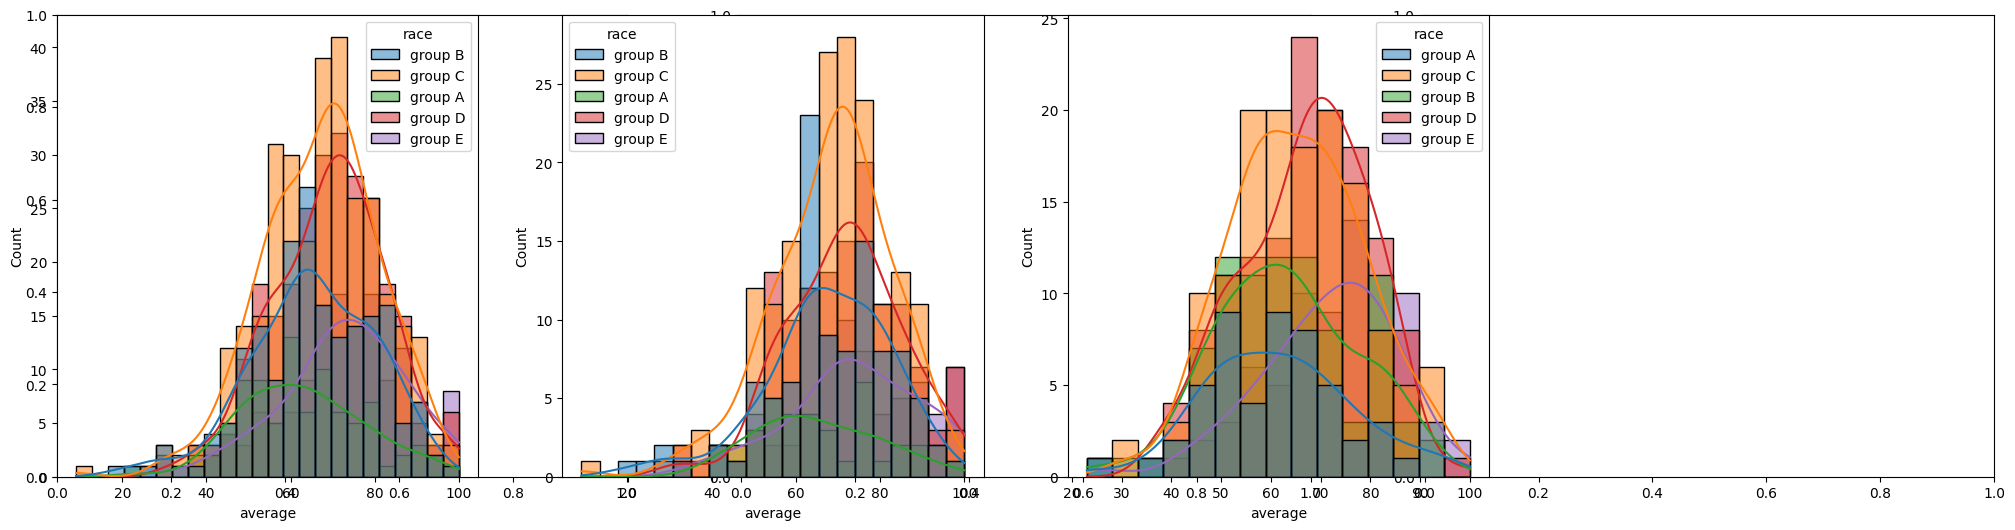

In [22]:
plt.subplots(1, 3, figsize = (25, 6))
plt.subplot(141)
sns.histplot(data = df, x = 'average', kde = True, hue = 'race')
plt.subplot(142)
sns.histplot(data = df[df.gender == 'female'], x = 'average', kde = True, hue = 'race')
plt.subplot(143)
sns.histplot(data = df[df.gender == 'male'], x = 'average', kde = True, hue = 'race')
plt.show()

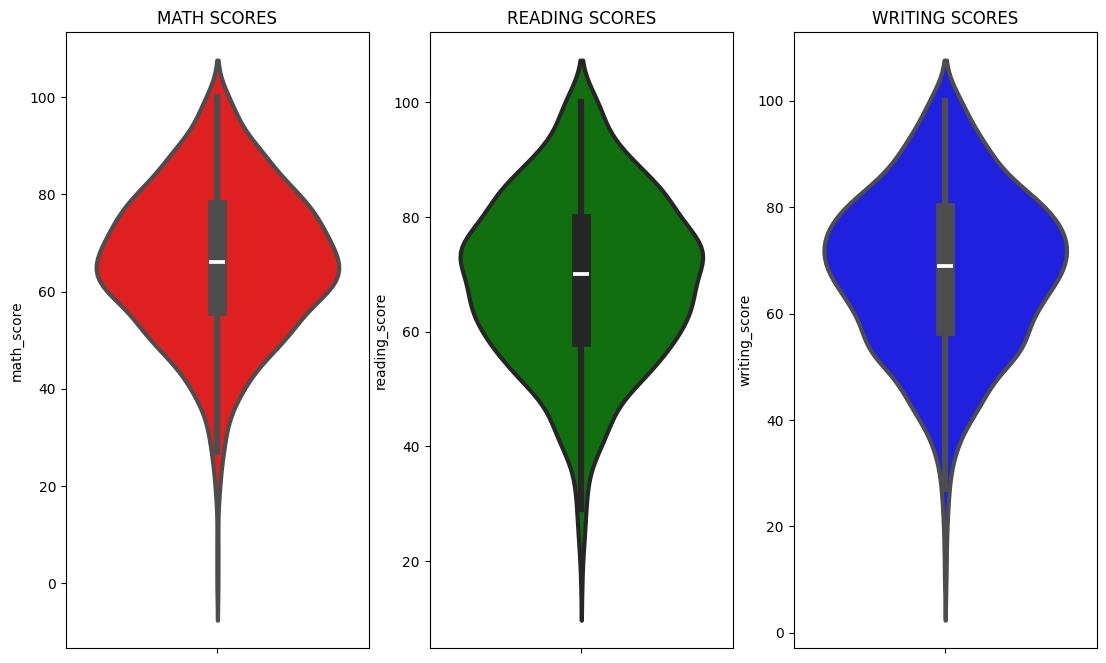

In [26]:
plt.figure(figsize = (18, 8))
plt.subplot(1, 4, 1)
plt.title('MATH SCORES')
sns.violinplot(y = 'math_score', data = df, color = 'red', linewidth = 3)
plt.subplot(1, 4, 2)
plt.title('READING SCORES')
sns.violinplot(y = 'reading_score', data = df, color = 'green', linewidth = 3)
plt.subplot(1, 4, 3)
plt.title('WRITING SCORES')
sns.violinplot(y = 'writing_score', data = df, color = 'blue', linewidth = 3)
plt.show()

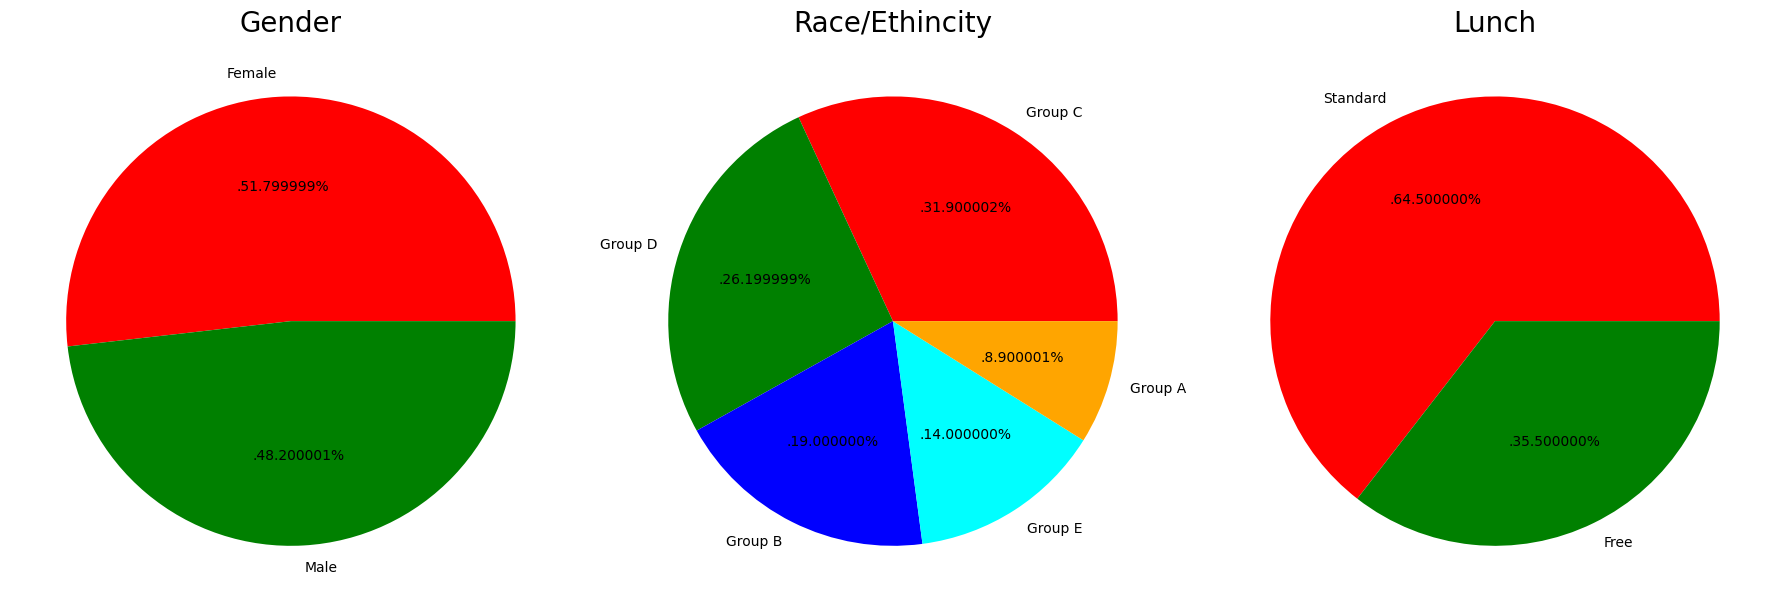

In [27]:

plt.rcParams['figure.figsize'] = (30, 12)

plt.subplot(1, 5, 1)
size = df['gender'].value_counts()
labels = 'Female', 'Male'
color = ['red', 'green']

plt.pie(size, colors = color, labels = labels, autopct = '.%2f%%')
plt.title('Gender', fontsize = 20)
plt.axis('off')

plt.subplot(1, 5, 2)
size = df['race'].value_counts()
labels = 'Group C', 'Group D', 'Group B', 'Group E', 'Group A'
color = ['red', 'green', 'blue', 'cyan', 'orange']

plt.pie(size, colors = color, labels = labels, autopct = '.%2f%%')
plt.title('Race/Ethincity', fontsize = 20)
plt.axis('off')

plt.subplot(1, 5, 3)
size = df['lunch'].value_counts()
labels = 'Standard', 'Free'
color = ['red', 'green']

plt.pie(size, colors = color, labels = labels, autopct = '.%2f%%')
plt.title('Lunch', fontsize = 20)
plt.axis('off')

plt.tight_layout()
plt.grid()
plt.show()


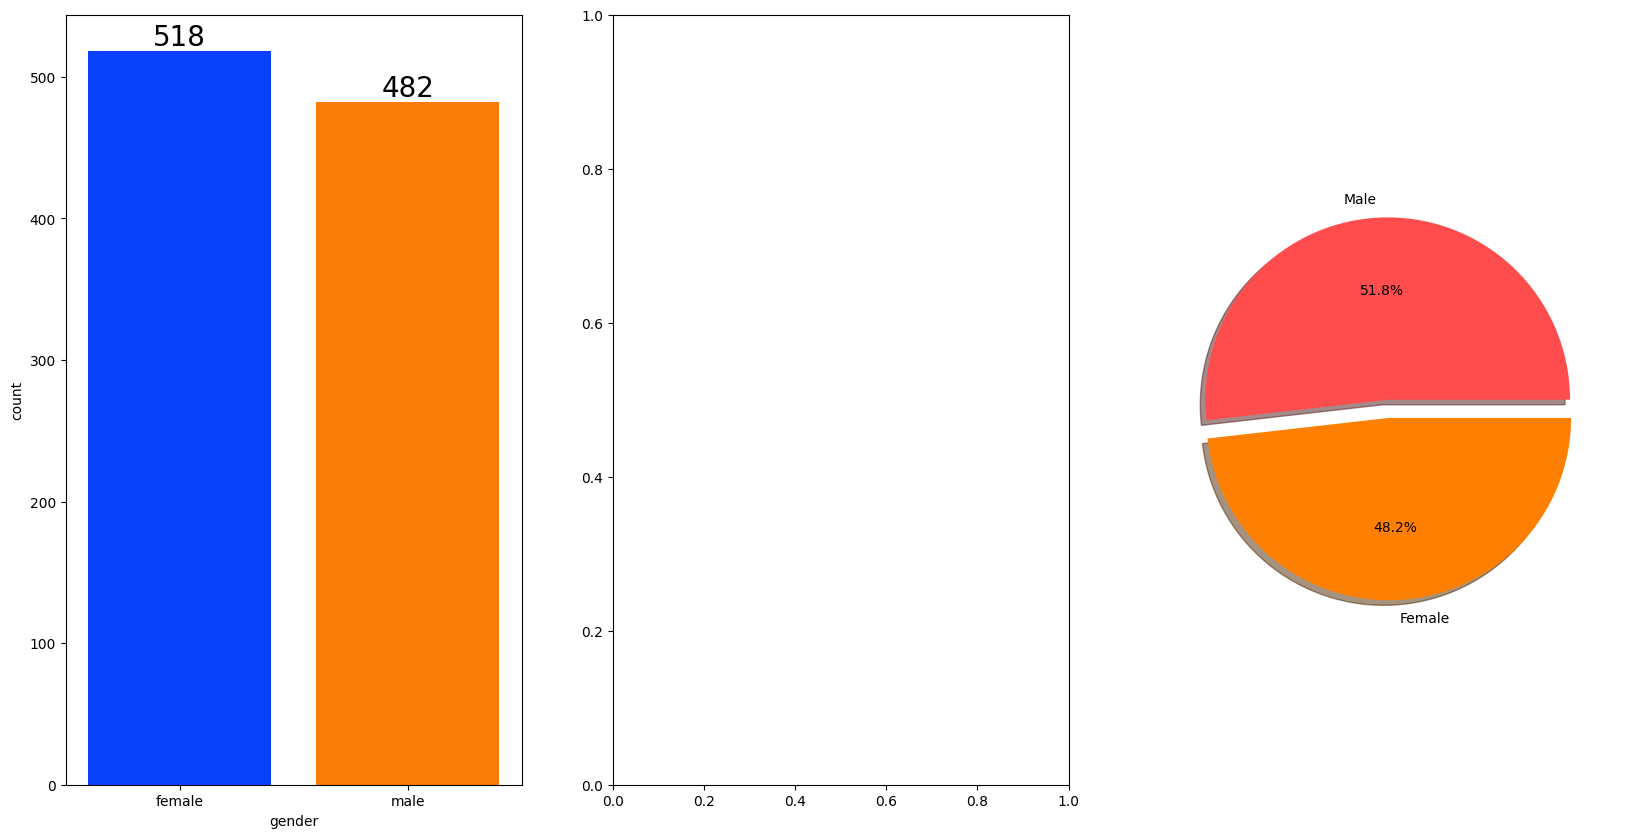

In [29]:

# Univariate Analysis

f, ax = plt.subplots(1, 3, figsize = (20, 10))
sns.countplot(x = df['gender'], data = df, palette = 'bright', ax = ax[0], saturation = 0.95)

for container in ax[0].containers:
    ax[0].bar_label(container, color = 'black', size = 20)

plt.pie(x = df['gender'].value_counts(), labels = ['Male', 'Female'], explode = [0, 0.1], autopct = '%1.1f%%', shadow = True, colors = ['#ff4d4d', '#ff8000'])
plt.show()


In [ ]:

# gender_group = df.groupby('gender').mean()
# gender_group


In [33]:
# Bivariate Analysis


# plt.figure(figsize = (10, 8))

# X = ['Total Average', 'Math Average']

# female_scores = [gender_group['average'][0], gender_group['math score'][0]]
# male_scores = [gender_group['average'][1], gender_group['math score'][1]]

# X_axis = np.arange(len(X))

# plt.bar(X_axis - 0.2, male_scores, 0.4, label = 'Male')
# plt.bar(X_axis + 0.2, female_scores, 0.4, label = 'Female')

# plt.xticks(X_axis, X)
# plt.ylabel("Marks")
# plt.title("Total average V/S Math Average marks of both the genders", fontweight = 'bold')
# plt.legend()
# plt.show()